In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from MSTOkG.MSTOOpt import *
from joblib import Parallel, delayed
import sys
from IPython.display import clear_output, display

In [4]:
dirname = "./demo/"
prefix = 'MOBS'
# choose your element
element = 'Li'

# get the default molecule in your basis
mol = moldict('sto-2g')[element]
# print the energy (HF and FCI)
Nmax = 10
# facs = [np.random.random(), 0]
tol = 1e-10
itermax=10

In [4]:

CreateMoleculesStdBasisSets(molecules=element, 
                            basissets=['6-31g', 'ccpvdz'], 
                            forcedump=False, dirname=dirname)


print(getEnergies(mol))


Done:   Li sto-2g
Done:   Li sto-3g
Done:   Li sto-4g
Done:   Li sto-5g
Done:   Li sto-6g
Done:   Li 6-31g
Done:   Li ccpvdz
{'HF': np.float64(-7.070820937427305), 'mol_HF': <pyscf.scf.rohf.ROHF object at 0x74ad6e992ee0>, 'CISD': np.float64(-7.071101199933796), 'mol_CISD': <pyscf.ci.ucisd.UCISD object at 0x74ad6e9bd700>}


In [5]:
for passes in range(1):
    for k in range(2, 13):
        print(f"pass {passes}; k={k}")
        mol = FetchBestMol(element, k, dirname=dirname) 
        fname = os.path.join(dirname, f"{prefix}_{element}_msto-{k:02d}g.pickle")
        pop2, gen, en = OptimizeElement(mol, Nmax, fname, trials=20, tol=tol, trials_mu=20, trials_co=20)
        print()
        # print("Trying an aggressive refinement")
        # AggressiveRefinement(pop2[0][1], fname, trials=10, tol=tol, fci=True, itermax=10)
        # print()

pass 0; k=2
[i:    3; M:   10; C:    0] Best:   -7.1149611 +/-    5.1424558 Ha, facs=[0.0009360684298833417, 0]

/home/subimal/miniconda3/envs/pyscf-env/lib/python3.9/site-packages/pyscf/ci/ucisd.py:881: RuntimeWarning: invalid value encountered in divide
  t1a = eris.focka[:nocca,nocca:].conj() / eia_a
/home/subimal/miniconda3/envs/pyscf-env/lib/python3.9/site-packages/pyscf/ci/ucisd.py:893: RuntimeWarning: invalid value encountered in divide
  t2aa /= lib.direct_sum('ia+jb->ijab', eia_a, eia_a)


[i:    5; M:   20; C:   19] Best:   -7.1458596 +/-            0 Ha, facs=[3.5590196673405716e-06, 0]]
pass 0; k=3
[i:    5; M:   20; C:   19] Best:   -7.3422842 +/-            0 Ha, facs=[2.2092671650570197e-06, 0]]
pass 0; k=4
[i:    5; M:   20; C:   19] Best:    -7.397709 +/-            0 Ha, facs=[3.4532890009322694e-06, 0]]
pass 0; k=5
[i:    4; M:   20; C:   19] Best:   -7.4211378 +/-            0 Ha, facs=[1.64396761449898e-05, 0]]]]
pass 0; k=6
[i:    4; M:   20; C:   19] Best:   -7.4273765 +/- 5.8212906e-07 Ha, facs=[3.025907340490427e-05, 0]
pass 0; k=7
[i:    2; M:   20; C:   19] Best:   -7.3960777 +/-            0 Ha, facs=[0.004736187002965806, 0]]
pass 0; k=8
[i:    1; M:   20; C:   19] Best:   -7.3933463 +/-            0 Ha, facs=[0.014528862211414173, 0]]
pass 0; k=9
[i:    2; M:   20; C:   19] Best:   -7.2739804 +/- 0.00083798449 Ha, facs=[0.005576075861105388, 0]
pass 0; k=10
[i:    2; M:   20; C:   19] Best:   -7.3353299 +/-            0 Ha, facs=[0.004477516780491719

Element: Li (Last update: 2025-29-11/19/25  15:29)
+--------+---------------------+--------------------+--------------------+
| Basis  | HF                  | FCI                | CISD               |
+--------+---------------------+--------------------+--------------------+
| 6-31g  | -7.4312349899801236 | -7.431554224800182 | -7.431553864032675 |
+--------+---------------------+--------------------+--------------------+
| ccpvdz | -7.432419879671086  | -7.432637514964849 | -7.432637291057477 |
+--------+---------------------+--------------------+--------------------+
+----+--------------------+---------------------+---------------------+---------------------+--------------------+---------------------+
| k  | HF (STO)           | HF (MSTO)           | FCI (STO)           | FCI (MSTO)          | CISD (STO)         | CISD (MSTO)         |
+----+--------------------+---------------------+---------------------+---------------------+--------------------+---------------------+
| 2  | -7.070

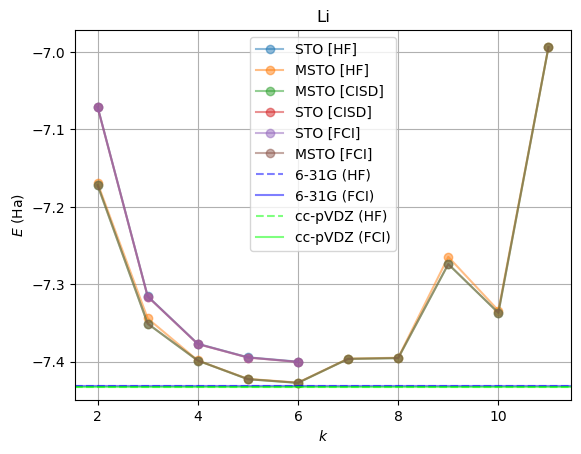

In [6]:
clear_output(wait=True)
fig = PrintEnergies(element, dirname = dirname, table=True, plot=True, prefix=prefix, 
              save=True, kmax=11)#, ylim=[-0.5, -0.485])

In [ ]:
for passes in range(1):
    for k in range(2, 13):
        print(f"pass {passes}; k={k}")
        mol = FetchBestMol(element, k, dirname=dirname) 
        fname = os.path.join(dirname, f"{prefix}_{element}_msto-{k:02d}g.pickle")
        # pop2, gen, en = OptimizeElement(mol, Nmax, fname, trials=20, tol=tol, trials_mu=20, trials_co=20)
        print()
        print("Trying an aggressive refinement")
        AggressiveRefinement(mol, fname, trials=10, tol=tol, fci=True, itermax=10)
        print()

pass 0; k=2

Trying an aggressive refinement
[i:    7.00000] Best:   -7.172031031493689 +/- 4.2e-08 Ha, facs=2.28e-06                     

Element: Li (Last update: 2025-29-11/19/25  13:29)
+--------+---------------------+--------------------+--------------------+
| Basis  | HF                  | FCI                | CISD               |
+--------+---------------------+--------------------+--------------------+
| 6-31g  | -7.4312349899801236 | -7.431554224800182 | -7.431553864032675 |
+--------+---------------------+--------------------+--------------------+
| ccpvdz | -7.432419879671086  | -7.432637514964849 | -7.432637291057477 |
+--------+---------------------+--------------------+--------------------+
+----+--------------------+---------------------+---------------------+---------------------+--------------------+---------------------+
| k  | HF (STO)           | HF (MSTO)           | FCI (STO)           | FCI (MSTO)          | CISD (STO)         | CISD (MSTO)         |
+----+--------------------+---------------------+---------------------+---------------------+--------------------+---------------------+
| 2  | -7.070

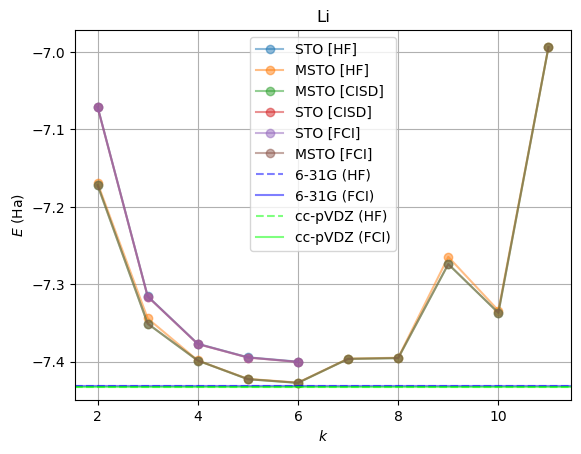

In [5]:
clear_output(wait=True)
fig = PrintEnergies(element, dirname = dirname, table=True, plot=True, prefix=prefix, 
              save=True, kmax=11)#, ylim=[-0.5, -0.485])

In [ ]:
print("Trying a logical (agressive) refinement")
LogicalRefinement(element, Nmax, trials=20, tol=tol, trials_mu=10, trials_co=10, 
                  prefix = 'MOBS', dirname=dirname, ga_trial=True, agg_trial=True, itermax=200)
print()

Trying a logical (agressive) refinement
k=3
k=4
k=5
k=6
k=7
k=8
k=9
[i:   19.00200] Best:  -0.4998238408325321 +/- 1e+09 Ha, facs=1.56e-09                       1, 0]]

[i:   19.00000] Best:   -0.499825119609315 +/- 5.32e-12 Ha, facs=4.82e-09                    88, 0]]

[i:    0] Best:  -0.49982512 +/-            0 Ha, facs=           0                    0682253, 0]

/opt/anaconda3/envs/science/lib/python3.12/site-packages/pyscf/gto/mole.py:119: RuntimeWarning: invalid value encountered in power
  return scipy.special.gamma(n1) / (2. * alpha**n1)


[i:    3.00200] Best:  -0.4998251196163391 +/- 1e+09 Ha, facs=0.018                     

In [ ]:
# k=8 is taking unusually long time to converge
# so we try an explicit agressive refinement

k=8
mol = FetchBestMol(element, k, dirname=dirname) 
fname = os.path.join(dirname, f"{prefix}_{element}_msto-{k:02d}g.pickle")

AggressiveRefinement(mol, fname, trials=50, tol=1e-16, fci=True, itermax=300)

[i:   14.00000] Best:  -0.4998491347354634 +/- 1.11e-13 Ha, facs=5.08e-10                    